In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
df.fillna(df.mean(), inplace=True)

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

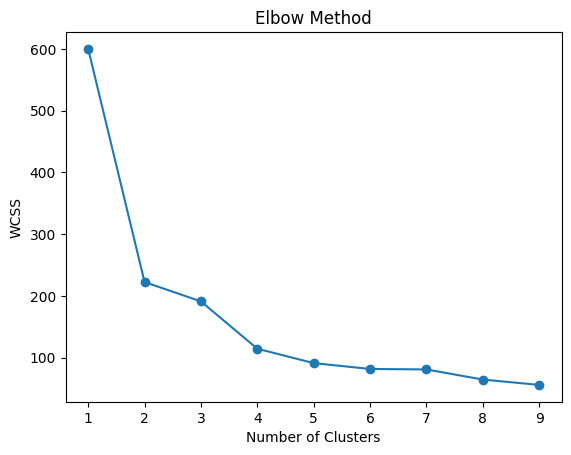

In [ ]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(scaled_data)

In [ ]:
kmeans_score = silhouette_score(scaled_data, kmeans_labels)
hc_score = silhouette_score(scaled_data, hc_labels)

print("KMeans Score:", kmeans_score)
print("Hierarchical Score:", hc_score)

KMeans Score: 0.4798814508199817
Hierarchical Score: 0.4466890410285909


In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

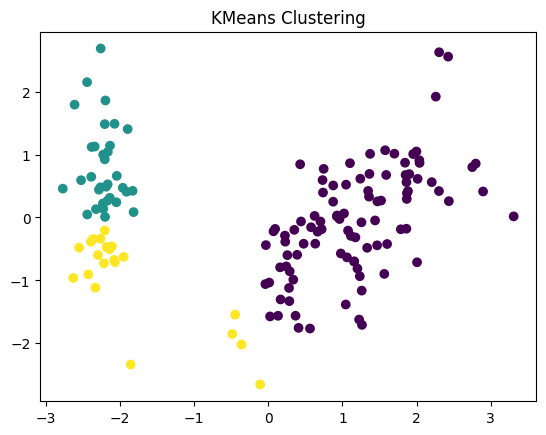

In [ ]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.show()

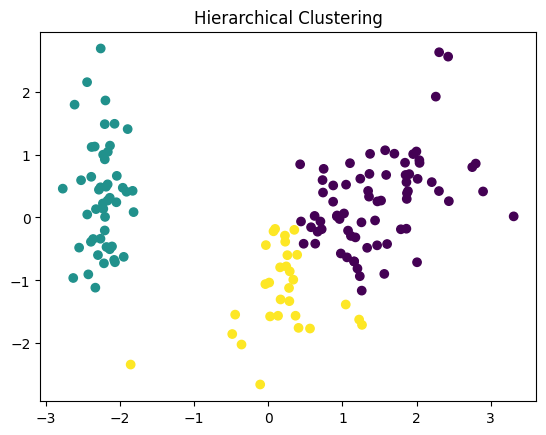

In [ ]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()

KMeans created 3 clusters clearly PCA shows separation visually
silhouette score indicates model performance compare both methods